In [ ]:
# Standard libraries
import os

# Matplotlib
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# OpenCV
import cv2

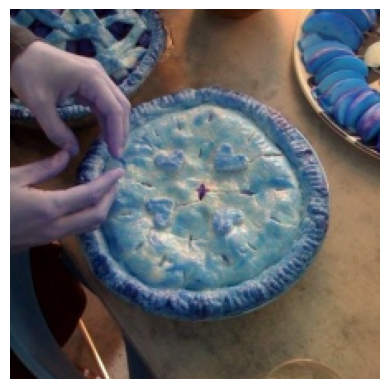

In [ ]:
import os, cv2
import matplotlib.pyplot as plt
import numpy as np

img = cv2.imread('.data/rgb_224/dessert/134.jpg', cv2.IMREAD_COLOR_RGB)

plt.axis('off')
plt.imshow(img)

## Constants

In [ ]:
SOURCE_IMAGE_DIR = ".data/images/"
GRAYSCALE_IMAGE_DIR = ".data/eval_grayscale"

CATEGORY_LABELS = [
    "not_food",
    "italian_food",
    "japanese_food",
    "fast_food",
    "meat",
    "seafood",
    "soup",
    "salad",
    "dessert",
    "rice",
    "eggs",
]

In [5]:
import cv2
import numpy as np

def resize_and_pad(image: cv2.Mat, target_size: tuple) -> cv2.Mat:
    height, width = image.shape[:2]
    center = np.array(image.shape[:2]) / 2
    
    # Get smallest side to determine the crop size
    crop = min(height, width)
    x = center[1] - crop / 2
    y = center[0] - crop / 2

    img_cropped = image[int(y):int(y+crop), int(x):int(x+crop)]

    # Crop the image to a square
    img_cropped = cv2.resize(img_cropped, target_size, interpolation=cv2.INTER_AREA)

    return img_cropped


## Generate Grayscale Images

In [6]:
import os, cv2

CATEGORY_LABELS = ['.']
SIZE = 224
SOURCE_IMAGE_DIR = ".data/eval/"
RGB_IMAGE_DIR = f".data/eval_rgb_{SIZE}/"

total_samples = 0

for img_dir in CATEGORY_LABELS:
    sample_count = len(os.listdir(os.path.join(SOURCE_IMAGE_DIR, img_dir)))
    print(f"Processing category: {img_dir} ({sample_count} samples)")
    total_samples += sample_count

    for filename in os.listdir(os.path.join(SOURCE_IMAGE_DIR, img_dir)):
        if not (filename.endswith(".jpg") or filename.endswith(".png")): continue
        
        # Processing
        img = cv2.imread(os.path.join(SOURCE_IMAGE_DIR, img_dir, filename), cv2.IMREAD_COLOR_RGB)
        img_resized = resize_and_pad(cv2.cvtColor(img, cv2.COLOR_BGR2RGB), target_size=(SIZE, SIZE))

        rgb_dir = os.path.join(RGB_IMAGE_DIR, f"{img_dir}")
        os.makedirs(rgb_dir, exist_ok=True)
        cv2.imwrite(os.path.join(rgb_dir, filename), img_resized)

        del img, img_resized

print("----------------------------------------")
print(f"Total samples processed: {total_samples}")

Processing category: . (134 samples)
----------------------------------------
Total samples processed: 134


In [ ]:
X, y = [], []

for img_dir in CATEGORY_LABELS:
    sample_count = len(os.listdir(os.path.join(GRAYSCALE_IMAGE_DIR, img_dir)))
    print(f"Importing category: {img_dir} ({sample_count} samples)")

    for filename in os.listdir(os.path.join(GRAYSCALE_IMAGE_DIR, img_dir)):
        if not (filename.endswith(".jpg") or filename.endswith(".png")): continue

        img = cv2.imread(os.path.join(GRAYSCALE_IMAGE_DIR, img_dir, filename), cv2.IMREAD_GRAYSCALE)
        X.append(img)
        y.append(CATEGORY_LABELS.index(img_dir))

print("------------------------------")
print(f"Data imported. Total samples: {len(X)}")

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from cnn import ResNet, Bottleneck

net = ResNet(Bottleneck, [2, 2, 2, 2], num_classes=len(CATEGORY_LABELS))
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

X_tensor = torch.tensor(X, dtype=torch.float32)  # Add channel dimension
y_tensor = torch.tensor(y, dtype=torch.int16)
dataset = TensorDataset(X_tensor, y_tensor)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

In [ ]:
for epoch in range(5):
    running_loss = 0.0
    for i, data in enumerate(dataloader, 0):
        inputs, labels = data
        optimizer.zero_grad()
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        if i % 200 == 199:
            print(f"[{epoch + 1}, {i + 1}] loss: {running_loss / 200:.3f}")
            running_loss = 0.0

print("Finished Training") 

## Evaluate Trained Model

In [15]:
import os, cv2, time, json
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
from IPython.display import Image, display, clear_output
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from cnn import ResNet, Bottleneck
from cnn import ResNet, Bottleneck

EVAL_IMAGE_DIR_GRAYSCALE = ".data/eval_rgb_224"
EVAL_IMAGE_METADATA_PATH = os.path.join(EVAL_IMAGE_DIR_GRAYSCALE, ".labels.json")
CATEGORY_LABELS = [
    "not_food",
    "italian_food",
    "japanese_food",
    "fast_food",
    "meat",
    "seafood",
    "soup",
    "salad",
    "dessert",
    "rice",
    "eggs",
]

TP, TN, FP, FN = 0, 0, 0, 0

label_file = open(EVAL_IMAGE_METADATA_PATH, "r")
eval_image_labels = json.load(label_file)
label_file.close()

net = ResNet(Bottleneck, [3, 4, 6, 3], num_classes=len(CATEGORY_LABELS), num_channels=3)
net.load_state_dict(torch.load("../models/resnet_food_classifier_big_epoch_10.pth", weights_only=True))
net.eval()


with torch.no_grad():
    eval_images = [img for img in sorted(os.listdir(os.path.join(EVAL_IMAGE_DIR_GRAYSCALE))) if not img.endswith(".json")]

    for img_path in eval_images:
        img = cv2.imread(os.path.join(EVAL_IMAGE_DIR_GRAYSCALE, img_path), cv2.IMREAD_COLOR_RGB).transpose(2, 0, 1) / 255.0  # Convert to CHW format and normalize
        
        tensor = torch.tensor(np.array(img), dtype=torch.float32).unsqueeze(0) # Add batch and channel dimensions
        prediction = net(tensor)
        probabilities = F.softmax(prediction, dim=1).numpy()[0]
        

        selected_label = CATEGORY_LABELS[np.argmax(probabilities)]
        
        if eval_image_labels[img_path] == "not_food":
            if selected_label == "not_food":
                TN += 1
            else:
                FN += 1
        else:
            if selected_label == "not_food":
                FP += 1
            else:
                TP += 1

        clear_output(wait=True)

accuracy = (TP + TN) / (TP + TN + FP + FN) * 100 if (TP + TN + FP + FN) > 0 else 0
precision = TP / (TP + FP) * 100 if (TP + FP) > 0 else 0
recall = TP / (TP + FN) * 100 if (TP + FN) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
print("EVALUATION RESULTS:")
print("------------------------------")

print("True Positives (TP):", TP)
print("True Negatives (TN):", TN)
print("False Positives (FP):", FP)
print("False Negatives (FN):", FN)
print("------------------------------")

print(f"1. Accuracy:\t{accuracy:.2f} %")
print(f"2. Precision:\t{precision:.2f} %")
print(f"3. Recall:\t{recall:.2f} %")
print(f"4. F1 Score:\t{f1_score:.2f} %")

EVALUATION RESULTS:
------------------------------
True Positives (TP): 61
True Negatives (TN): 58
False Positives (FP): 4
False Negatives (FN): 11
------------------------------
1. Accuracy:	88.81 %
2. Precision:	93.85 %
3. Recall:	84.72 %
4. F1 Score:	89.05 %


PREDICTION RESULTS:
------------------------------
0. not_food: 0.3821
1. italian_food: 0.0009
2. japanese_food: 0.0019
3. fast_food: 0.0016
4. meat: 0.0001
5. seafood: 0.0007
6. soup: 0.4513
7. salad: 0.0004
8. dessert: 0.1478
9. rice: 0.0065
10. eggs: 0.0065

PREDICTION: soup


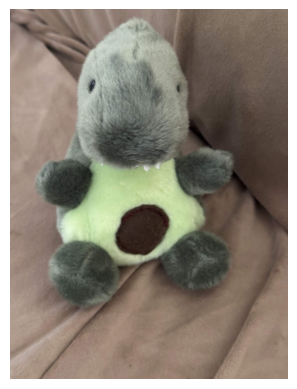

In [ ]:
import os, cv2, time, json
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
from IPython.display import Image, display, clear_output
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from cnn import ResNet, Bottleneck
from cnn import ResNet, Bottleneck


EVAL_IMAGE = ".data/IMG_3164.jpg"

CATEGORY_LABELS = [
    "not_food",
    "italian_food",
    "japanese_food",
    "fast_food",
    "meat",
    "seafood",
    "soup",
    "salad",
    "dessert",
    "rice",
    "eggs",
]

TP, TN, FP, FN = 0, 0, 0, 0


net = ResNet(Bottleneck, [3, 4, 6, 3], num_classes=len(CATEGORY_LABELS), num_channels=3)
net.load_state_dict(torch.load("../models/resnet_food_classifier_big_epoch_10.pth", weights_only=True))
net.eval()


image_file = cv2.imread(EVAL_IMAGE, cv2.IMREAD_COLOR_RGB).transpose(2, 0, 1) / 255.0  # Convert to CHW format and normalize

with torch.no_grad():
    tensor = torch.tensor(np.array(image_file), dtype=torch.float32).unsqueeze(0) # Add batch and channel dimensions
    prediction = net(tensor)
    probabilities = F.softmax(prediction, dim=1).numpy()[0]
        


print("PREDICTION RESULTS:")
print("------------------------------")
for idx, (label, prob) in enumerate(zip(CATEGORY_LABELS, probabilities)):
    print(f"{idx}. {label}: {prob:.4f}")

selected_label = CATEGORY_LABELS[np.argmax(probabilities)]
print("------------------------------")
print(f"\nPREDICTION: {selected_label}")

plt.axis('off')
plt.imshow(image_file.transpose(1, 2, 0))

## Appendix: Image Labeling

In [6]:
import json, os
from IPython.display import Image, display, clear_output

EVAL_IMAGE_DIR = ".data/eval_rgb_224/"
EVAL_IMAGE_METADATA_PATH = os.path.join(EVAL_IMAGE_DIR, ".labels.json")

CATEGORY_LABELS = [
    "not_food",
    "italian_food",
    "japanese_food",
    "fast_food",
    "meat",
    "seafood",
    "soup",
    "salad",
    "dessert",
    "rice",
    "eggs",
]

label_file = open(EVAL_IMAGE_METADATA_PATH, "r")
eval_image_labels = json.load(label_file)
label_file.close()

eval_images = [img for img in sorted(os.listdir(EVAL_IMAGE_DIR)) if not img.endswith(".json")]

for img_path in eval_images:
    if img_path in eval_image_labels: continue  # Skip if label already exists
    display(Image(os.path.join(EVAL_IMAGE_DIR, img_path)))
    
    try:
        label = input("image label: ").strip().lower()
        assert label in CATEGORY_LABELS, f"Invalid label. Please enter one of the following: {', '.join(CATEGORY_LABELS)}"
        eval_image_labels[img_path] = label
        clear_output(wait=True)
    
    except AssertionError as e:
        label_file = open(EVAL_IMAGE_METADATA_PATH, "w")
        json.dump(eval_image_labels, label_file, indent=4)
        label_file.close()
        raise e

label_file = open(EVAL_IMAGE_METADATA_PATH, "w")
print("All images labeled. Saving labels to file.") 
json.dump(eval_image_labels, label_file, indent=4)
label_file.close()


All images labeled. Saving labels to file.


In [ ]:
# Get label for one image


EVALUATION RESULTS: (epoch = 20)

- True Positives (TP): 60
- True Negatives (TN): 61
- False Positives (FP): 9
- False Negatives (FN): 4

1. Accuracy: 90.30%
2. Precision: 86.96%
3. Recall: 93.75%
4. F1 Score: 90.23%